In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from abm.rewards_clean import create_mexican_hat_gp_single
from abm.performance_comparison import gaussian_walk
from abm.utils import plot_reward_grid
from abm.reporter_helpers import min_distance_to_points

In [3]:
def find_local_peak_coordinates(reward_map: np.ndarray) -> np.ndarray:
    """Return coordinates of local maxima in a 2D reward map (8-neighborhood), sorted by value in descending order."""
    n_rows, n_cols = reward_map.shape
    padded_map = np.pad(reward_map, 1, mode="constant", constant_values=-np.inf)
    center = padded_map[1:-1, 1:-1]

    is_local_peak = np.ones_like(reward_map, dtype=bool)
    for row_shift in (-1, 0, 1):
        for col_shift in (-1, 0, 1):
            if row_shift == 0 and col_shift == 0:
                continue
            neighbor = padded_map[
                1 + row_shift : 1 + row_shift + n_rows,
                1 + col_shift : 1 + col_shift + n_cols,
            ]
            is_local_peak &= center >= neighbor

    peaks = np.argwhere(is_local_peak)
    # Sort peaks by their value in reward_map in descending order
    sorted_peaks = peaks[np.argsort(-reward_map[peaks[:, 0], peaks[:, 1]])]

    return sorted_peaks[1:]

def is_at_global_max(max_coords, path, radius=1):
    return np.linalg.norm(path - max_coords, axis=1) <= radius

def is_at_local_max(local_maxima, path, radius=1):
    map_min_dist = lambda choice : min_distance_to_points(choice, local_maxima)
    min_dist = np.array(list(map(map_min_dist, path)))
    return min_dist <= radius

import numpy as np

def max_up_to_T(matrix):
    """
    Compute the maximum observation up to time T for each trial, then average across trials.

    Args:
        matrix: 2D NumPy array with shape (time, trial)

    Returns:
        1D NumPy array of shape (time,) containing the average maximum up to each time T
    """
    # Compute the cumulative maximum along the time axis for each trial
    cummax = np.maximum.accumulate(matrix.T, axis=0)

    # Average across trials (axis=1)
    avg_max = np.mean(cummax, axis=1)

    return avg_max

In [4]:
rng = np.random.default_rng(seed=42)
grid_size = 20
length_scale = 3

steps = 50
sigma = 1

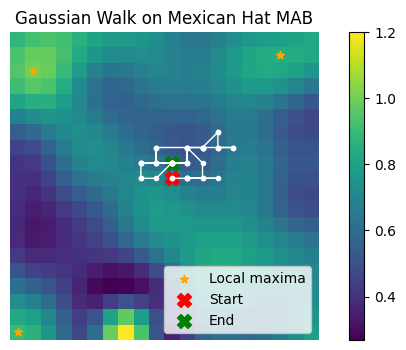

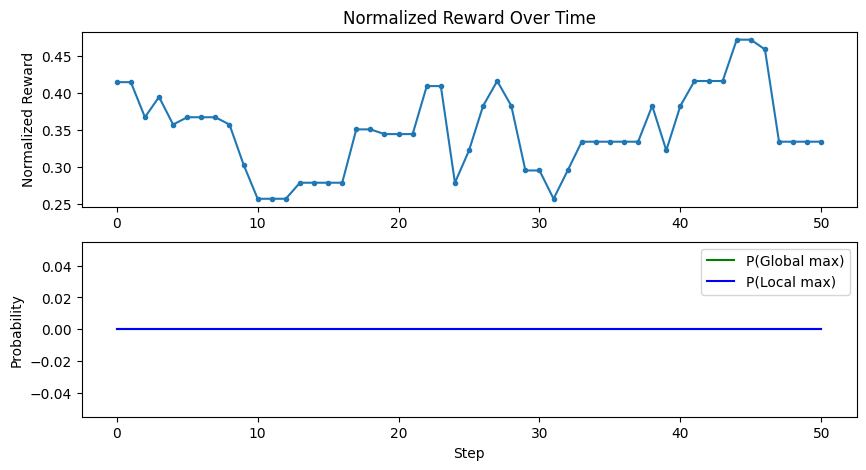

In [10]:
grid, max_coords = create_mexican_hat_gp_single(rng=rng, grid_size=grid_size, length_scale=length_scale)
local_maxima = find_local_peak_coordinates(grid)
path, results = gaussian_walk(grid=grid, steps=steps, sigma=sigma, rng=rng)

# plot path colored by step number, with different start and end markers
fig = plot_reward_grid(grid)
plt.scatter(local_maxima[:3,1], local_maxima[:3,0], marker='*', color='orange', label='Local maxima')
plt.plot(path[:, 1], path[:, 0], marker='o', markersize=3, color='white', linewidth=1)
plt.scatter(path[0, 1], path[0, 0], marker='X', s=100, color='red', label='Start')  
plt.scatter(path[-1, 1], path[-1, 0], marker='X', s=100, color='green', label='End')
plt.legend()
plt.title('Gaussian Walk on Mexican Hat MAB')
plt.show()

# plot reaward over time (normalized by max and mean reward of grid)
fig, ax = plt.subplots(2, 1, figsize=(10,5))
ax[0].plot((results - np.min(grid)) / (np.max(grid) - np.min(grid)), marker='o', markersize=3)
ax[0].set_title('Normalized Reward Over Time')
ax[0].set_ylabel('Normalized Reward')

# plot choice probabilities
p_global = is_at_global_max(max_coords, path)
p_local  = is_at_local_max(local_maxima[:3], path)
ax[1].plot(p_global, color='green', label='P(Global max)')
ax[1].plot(p_local, color='blue', label='P(Local max)')
ax[1].set_xlabel('Step')
ax[1].set_ylabel('Probability')
ax[1].legend()

# # plot histogram of reward values
# ax[1].hist(grid.flatten(), bins=30)
# ax[1].set_title('Histogram of Reward Values') 
# # plot mean and median lines
# ax[1].vlines([grid.flatten().mean(), np.median(grid.flatten())], [0,0], [40,40], colors=["black", "red"])
plt.show()

In [5]:
def run_gaussian_walk_batch(num_grids=10, walks_per_grid=20, steps=50, grid_size=20, length_scale=3, sigma=2, seed=42):
    """
    Runs a batch pipeline across multiple grids and walks, tracking 
    normalized rewards and maximum-state probabilities over time.
    """
    rng = np.random.default_rng(seed=seed)
    
    # Master lists to hold data across all runs
    all_normalized_rewards = []
    all_p_global = []
    all_p_local = []
    
    for g in range(num_grids):
        # 1. Generate a new grid distribution (Option C)
        grid, max_coords = create_mexican_hat_gp_single(
            rng=rng, grid_size=grid_size, length_scale=length_scale
        )
        local_maxima = find_local_peak_coordinates(grid)
        
        grid_min = np.min(grid)
        grid_max = np.max(grid)
        grid_range = grid_max - grid_min
        
        for w in range(walks_per_grid):
            # 2. Run the gaussian walk
            path, results = gaussian_walk(grid=grid, steps=steps, sigma=sigma, rng=rng)
            
            # 3. Process and normalize rewards
            normalized_res = (results - grid_min) / grid_range
            all_normalized_rewards.append(normalized_res)
            
            # 4. Check positioning (returns boolean arrays)
            p_global = is_at_global_max(max_coords, path)
            p_local  = is_at_local_max(local_maxima[:3], path)
            
            all_p_global.append(p_global)
            all_p_local.append(p_local)
            
    # Convert lists to matrices: shape (num_simulations, steps + 1)
    return (
        np.array(all_normalized_rewards), 
        np.array(all_p_global), 
        np.array(all_p_local)
    )

# --- Run the batch pipeline ---
reward_matrix, global_matrix, local_matrix = run_gaussian_walk_batch(
    num_grids=1, walks_per_grid=100, steps=50
)

# Compute reward statistics
mean_rewards = np.mean(reward_matrix, axis=0)
std_rewards = np.std(reward_matrix, axis=0)
sem_rewards = std_rewards / np.sqrt(reward_matrix.shape[0])

# Compute empirical probabilities (mean of 1s and 0s)
mean_p_global = np.mean(global_matrix, axis=0)
mean_p_local = np.mean(local_matrix, axis=0)

# Optional: SEM for probabilities 
sem_p_global = np.std(global_matrix, axis=0) / np.sqrt(global_matrix.shape[0])
sem_p_local = np.std(local_matrix, axis=0) / np.sqrt(local_matrix.shape[0])

In [11]:
def run_uniform_sampling_batch(num_grids=10, walks_per_grid=20, steps=50, grid_size=20, length_scale=3, seed=42):
    """
    Runs a batch pipeline across multiple grids and walks, using uniform sampling with replacement.
    Tracks normalized rewards and maximum-state probabilities over time.
    """
    rng = np.random.default_rng(seed=seed)

    # Master lists to hold data across all runs
    all_normalized_rewards = []
    all_p_global = []
    all_p_local = []

    for g in range(num_grids):
        # 1. Generate a new grid distribution (Option C)
        grid, max_coords = create_mexican_hat_gp_single(
            rng=rng, grid_size=grid_size, length_scale=length_scale
        )
        local_maxima = find_local_peak_coordinates(grid)

        grid_min = np.min(grid)
        grid_max = np.max(grid)
        grid_range = grid_max - grid_min

        for w in range(walks_per_grid):
            # 2. Run uniform sampling with replacement
            # Flatten grid coordinates for sampling
            flat_indices = np.arange(grid_size * grid_size)
            sampled_indices = rng.choice(flat_indices, size=steps+1, replace=True)
            path = np.array([np.unravel_index(idx, (grid_size, grid_size)) for idx in sampled_indices])
            # Get the grid values at the sampled positions
            results = grid[path[:, 0], path[:, 1]]

            # 3. Process and normalize rewards
            normalized_res = (results - grid_min) / grid_range
            all_normalized_rewards.append(normalized_res)

            # 4. Check positioning (returns boolean arrays)
            p_global = is_at_global_max(max_coords, path)
            p_local  = is_at_local_max(local_maxima[:3], path)

            all_p_global.append(p_global)
            all_p_local.append(p_local)

    # Convert lists to matrices: shape (num_simulations, steps + 1)
    return (
        np.array(all_normalized_rewards),
        np.array(all_p_global),
        np.array(all_p_local)
    )

# --- Run the batch pipeline ---
reward_matrix_iid, global_matrix_iid, local_matrix_iid = run_uniform_sampling_batch(
    num_grids=1, walks_per_grid=100, steps=50
)

mean_rewards_iid = np.mean(reward_matrix_iid, axis=0)

# Compute empirical probabilities (mean of 1s and 0s)
mean_p_global_iid = np.mean(global_matrix, axis=0)
mean_p_local_iid = np.mean(local_matrix, axis=0)

# Optional: SEM for probabilities if you want to shade them too
sem_p_global_iid = np.std(global_matrix, axis=0) / np.sqrt(global_matrix.shape[0])
sem_p_local_iid = np.std(local_matrix, axis=0) / np.sqrt(local_matrix.shape[0])

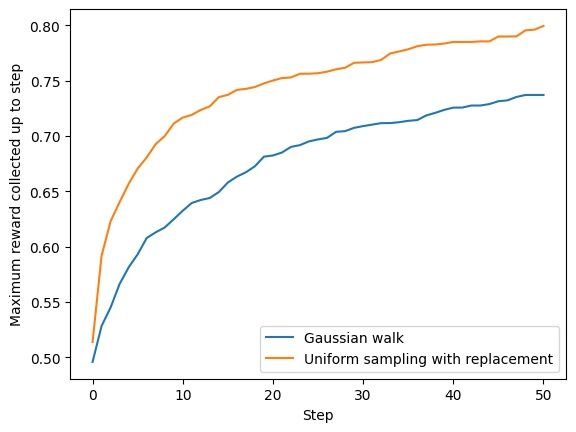

In [10]:
plt.plot(max_up_to_T(reward_matrix), label='Gaussian walk')
plt.plot(max_up_to_T(reward_matrix_iid), label='Uniform sampling with replacement')
plt.xlabel('Step')
plt.ylabel('Maximum reward collected up to step')
plt.legend()
plt.show()

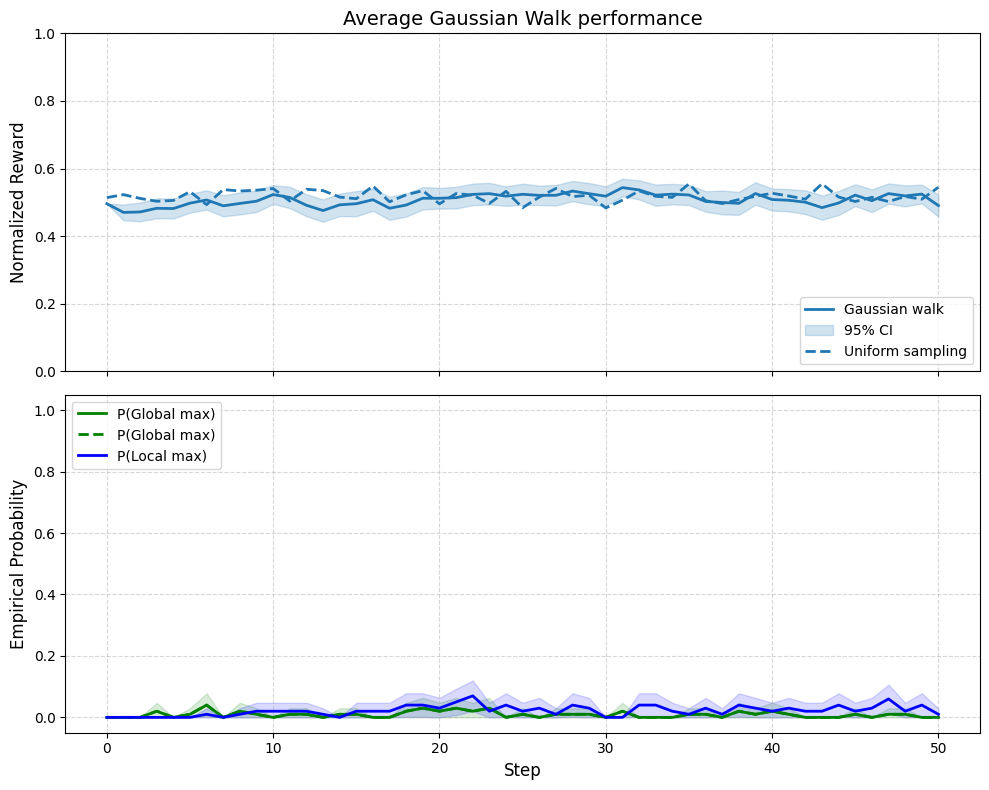

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
steps_axis = np.arange(len(mean_rewards))

# --- Panel 1: Normalized Reward ---
ax[0].plot(steps_axis, mean_rewards, color='#1f77b4', lw=2, label='Gaussian walk')
ax[0].fill_between(
    steps_axis, 
    mean_rewards - 1.96 * sem_rewards, 
    mean_rewards + 1.96 * sem_rewards, 
    color='#1f77b4', alpha=0.2, label='95% CI'
)
ax[0].plot(steps_axis, mean_rewards_iid, '--', color='#1f77b4', lw=2, label='Uniform sampling')
ax[0].set_title('Average Gaussian Walk performance', fontsize=14)
ax[0].set_ylabel('Normalized Reward', fontsize=12)
ax[0].set_ylim([0,1])
ax[0].grid(True, linestyle='--', alpha=0.5)
ax[0].legend(loc='lower right')


# --- Panel 2: State Choice Probabilities ---
# Global Max Plot
ax[1].plot(steps_axis, mean_p_global, color='green', lw=2, label='P(Global max)')
ax[1].fill_between(
    steps_axis,
    np.clip(mean_p_global - 1.96 * sem_p_global, 0, 1), # clipped to stay within valid [0,1] probability range
    np.clip(mean_p_global + 1.96 * sem_p_global, 0, 1),
    color='green', alpha=0.15
)
ax[1].plot(steps_axis, mean_p_global_iid, '--', color='green', lw=2, label='P(Global max)')

# Local Max Plot
ax[1].plot(steps_axis, mean_p_local, color='blue', lw=2, label='P(Local max)')
ax[1].fill_between(
    steps_axis,
    np.clip(mean_p_local - 1.96 * sem_p_local, 0, 1),
    np.clip(mean_p_local + 1.96 * sem_p_local, 0, 1),
    color='blue', alpha=0.15
)

ax[1].set_xlabel('Step', fontsize=12)
ax[1].set_ylabel('Empirical Probability', fontsize=12)
ax[1].set_ylim(-0.05, 1.05) # Keeps the probability scale bounded nicely
ax[1].grid(True, linestyle='--', alpha=0.5)
ax[1].legend(loc='upper left')

plt.tight_layout()
plt.show()